# Часть 1

## Этап 1

In [1]:
# 1. Импорт необходимых библиотек

# Базовые библиотеки для работы с данными
import pandas as pd
import numpy as np

# Библиотеки для визуализации
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля для графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Игнорируем предупреждения для чистоты вывода
import warnings
warnings.filterwarnings('ignore')

print("Библиотеки успешно импортированы!")

Библиотеки успешно импортированы!


In [2]:
# 2. Загрузка датасета
dataset_file_path = 'uplift_fp_data.csv'
df = pd.read_csv(dataset_file_path)
df.sample(5)

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
56505,6,0,57.46,0,1,0,0,1,1,1
5370,9,0,96.32,0,1,1,1,1,1,1
4184,9,0,81.36,0,1,1,1,1,0,0
315,1,1,188.89,0,1,1,1,2,0,0
12466,1,1,154.69,1,0,2,1,2,1,0


In [7]:
# Информация о датасете
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  int64  
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  int64  
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  int64  
 8   treatment        64000 non-null  int64  
 9   target           64000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 4.9 MB


In [8]:
# Статистическое описание числовых признаков
df.describe()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
count,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000
mean,5.763734,1.481969,242.085656,0.551031,0.549719,0.748469,0.502250,1.319609,0.334172,0.146781
std,3.507592,1.544514,256.158608,0.497393,0.497526,0.697936,0.499999,0.678254,0.471704,0.353890
min,1.000000,0.000000,29.990000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,64.660000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,6.000000,1.000000,158.110000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
75%,9.000000,2.000000,325.657500,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,0.000000
max,12.000000,6.000000,3345.930000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000


In [3]:
# Проверка на пропуски и их заполнение

print("Проверка на пропуски (до обработки):")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if any(missing_values > 0) else "Пропусков не найдено!")

# Если есть пропуски, заполним их
if any(missing_values > 0):
    print("\nОбнаружены пропуски. Заполняем...")
    
    # Для числовых признаков заполняем медианой
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if df[col].isnull().sum() > 0:
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            print(f"Заполнены пропуски в {col} медианой ({median_val})")
    
    # Для категориальных признаков заполняем модой
    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if df[col].isnull().sum() > 0:
            mode_val = df[col].mode()[0]
            df[col].fillna(mode_val, inplace=True)
            print(f"Заполнены пропуски в {col} модой ({mode_val})")
    
    print("\nПроверка после заполнения пропусков:")
    print(df.isnull().sum())
else:
    print("\nПропусков нет, данные чистые.")

Проверка на пропуски (до обработки):
Пропусков не найдено!

Пропусков нет, данные чистые.


In [4]:
# Дополнительная проверка на дубликаты
duplicates = df.duplicated().sum()
print(f"Количество дубликатов: {duplicates}")
if duplicates > 0:
    print('Сэмпл дубликатов:')
    display(df.loc[df.duplicated(keep=False)].drop_duplicates().sort_values(by=df.columns.to_list()).head(10))
    old_len = len(df)
    print('Размер датасета до очистки от дубликатов: ', old_len)
    df = df.drop_duplicates()
    print('Размер датасета после удаления дубликатов: ', len(df), f'Новый размер составляет: {len(df) / old_len * 100}%')

Количество дубликатов: 7015
Сэмпл дубликатов:


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
2612,1,0,29.99,0,1,0,0,1,0,0
1749,1,0,29.99,0,1,0,0,1,0,1
5104,1,0,29.99,0,1,0,0,1,1,0
13197,1,0,29.99,0,1,0,0,1,1,1
728,1,0,29.99,0,1,0,0,2,0,0
21998,1,0,29.99,0,1,0,0,2,0,1
692,1,0,29.99,0,1,0,0,2,1,0
7342,1,0,29.99,0,1,0,0,2,1,1
3065,1,0,29.99,0,1,0,1,1,0,0
42235,1,0,29.99,0,1,0,1,1,0,1


Размер датасета до очистки от дубликатов:  64000
Размер датасета после удаления дубликатов:  56985 Новый размер составляет: 89.0390625%


In [5]:
# Итоговая информация о подготовленных данных
print("\n" + "="*50)
print("ИТОГИ ЭТАПА 1: ПЕРВИЧНАЯ ПОДГОТОВКА ДАННЫХ")
print("="*50)
print(f"Размер датасета после обработки: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"Количество пропусков: {df.isnull().sum().sum()}")
print(f"Типы данных:\n{df.dtypes}")



ИТОГИ ЭТАПА 1: ПЕРВИЧНАЯ ПОДГОТОВКА ДАННЫХ
Размер датасета после обработки: 56985 строк, 10 столбцов
Количество пропусков: 0
Типы данных:
recency              int64
history_segment      int64
history            float64
mens                 int64
womens               int64
zip_code             int64
newbie               int64
channel              int64
treatment            int64
target               int64
dtype: object


## Этап 2

### EDA


In [24]:
# Настройка стиля для графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
sns.set_context("notebook", font_scale=1.2)

print("="*60)
print("ЭТАП 2: ИССЛЕДОВАТЕЛЬСКИЙ АНАЛИЗ ДАННЫХ")
print("="*60)

ЭТАП 2: ИССЛЕДОВАТЕЛЬСКИЙ АНАЛИЗ ДАННЫХ


In [25]:
# Анализ распределения между контрольной и тестовой группами

print("Распределение пользователей по группам (treatment):")
treatment_distribution = df['treatment'].value_counts()
treatment_distribution_percent = df['treatment'].value_counts(normalize=True) * 100

treatment_df = pd.DataFrame({
    'Количество': treatment_distribution,
    'Процент': treatment_distribution_percent.round(2)
})
treatment_df.index = ['Контрольная группа (0)', 'Тестовая группа (1)']
display(treatment_df)
print("\n" + "="*50)

Распределение пользователей по группам (treatment):


,Количество,Процент
Контрольная группа (0),37826,66.38
Тестовая группа (1),19159,33.62


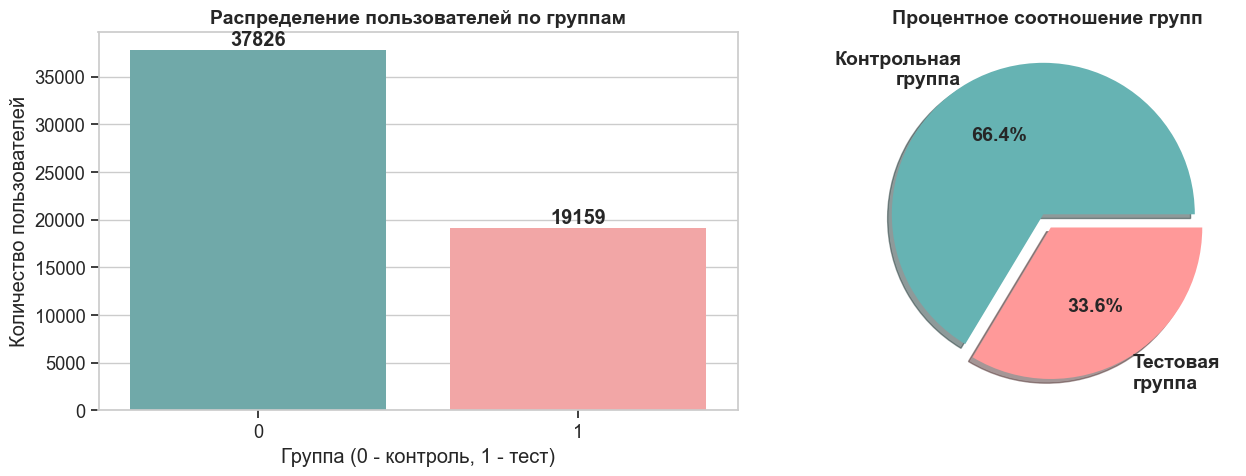

In [26]:
# Визуализация распределения по группам
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Количество пользователей в группах
sns.countplot(data=df, x='treatment', ax=axes[0], palette=['#66b3b3', '#ff9999'])
axes[0].set_title('Распределение пользователей по группам', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Группа (0 - контроль, 1 - тест)')
axes[0].set_ylabel('Количество пользователей')
for i, v in enumerate(treatment_distribution.values):
    axes[0].text(i, v + 500, str(v), ha='center', fontweight='bold')

# График 2: Процентное соотношение
axes[1].pie(treatment_distribution.values, 
            labels=['Контрольная\nгруппа', 'Тестовая\nгруппа'],
            autopct='%1.1f%%',
            colors=['#66b3b3', '#ff9999'],
            explode=(0.05, 0.05),
            shadow=True,
            textprops={'fontsize': 14, 'fontweight': 'bold'})
axes[1].set_title('Процентное соотношение групп', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [29]:
# Анализ целевой переменной (конверсии) по группам

print("\nАнализ конверсии (target) по группам:")
print("-" * 50)

# Общая конверсия
overall_conversion = df['target'].mean() * 100
print(f"Общая конверсия по всем пользователям: {overall_conversion:.2f}%")

# Конверсия по группам
conversion_by_group = df.groupby('treatment')['target'].agg(['mean', 'count', 'sum'])
conversion_by_group['mean'] = conversion_by_group['mean'] * 100
conversion_by_group.columns = ['Конверсия (%)', 'Кол-во пользователей', 'Кол-во конверсий']
conversion_by_group.index = ['Контрольная группа (0)', 'Тестовая группа (1)']

print("\nКонверсия по группам:")
display(conversion_by_group.round(2))

# Lift от промокода
control_conv = conversion_by_group.loc['Контрольная группа (0)', 'Конверсия (%)']
treatment_conv = conversion_by_group.loc['Тестовая группа (1)', 'Конверсия (%)']
lift = treatment_conv - control_conv
relative_lift = (treatment_conv - control_conv) / control_conv * 100

print(f"\nАбсолютный lift от промокода: {lift:.2f} п.п.")
print(f"Относительный lift: {relative_lift:.2f}%")


Анализ конверсии (target) по группам:
--------------------------------------------------
Общая конверсия по всем пользователям: 15.52%

Конверсия по группам:


,Конверсия (%),Кол-во пользователей,Кол-во конверсий
Контрольная группа (0),15.27,37826,5775
Тестовая группа (1),16.02,19159,3069



Абсолютный lift от промокода: 0.75 п.п.
Относительный lift: 4.92%


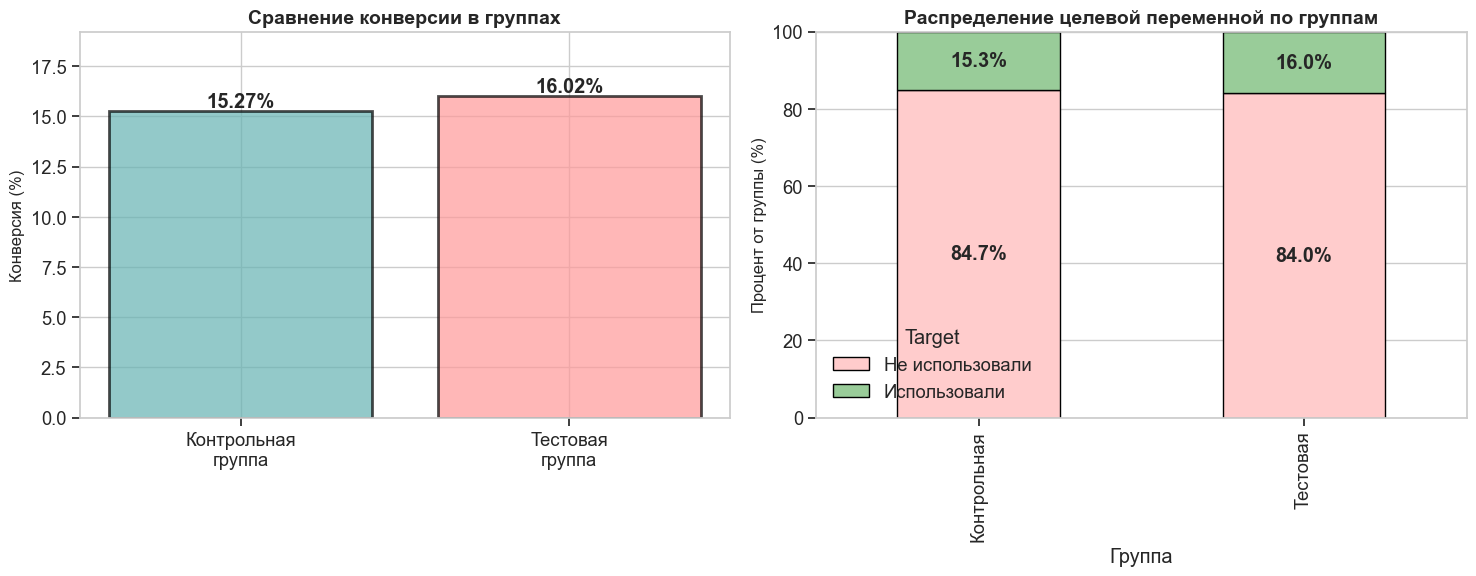

In [30]:
# Визуализация конверсии по группам
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# График 1: Сравнение конверсии
bars = axes[0].bar(['Контрольная\nгруппа', 'Тестовая\nгруппа'], 
                   [control_conv, treatment_conv],
                   color=['#66b3b3', '#ff9999'],
                   edgecolor='black',
                   linewidth=2,
                   alpha=0.7)
axes[0].set_ylabel('Конверсия (%)', fontsize=12)
axes[0].set_title('Сравнение конверсии в группах', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, max(control_conv, treatment_conv) * 1.2)

# Добавляем значения на столбцы
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.2f}%', ha='center', va='bottom', fontweight='bold')

# График 2: Матрица распределения
# Создаем сводную таблицу
pivot_table = pd.crosstab(df['treatment'], df['target'], 
                          normalize='index') * 100
pivot_table.columns = ['Не использовали (0)', 'Использовали (1)']
pivot_table.index = ['Контрольная', 'Тестовая']

pivot_table.plot(kind='bar', stacked=True, ax=axes[1], 
                 color=['#ffcccc', '#99cc99'],
                 edgecolor='black',
                 linewidth=1)
axes[1].set_ylabel('Процент от группы (%)', fontsize=12)
axes[1].set_xlabel('Группа')
axes[1].set_title('Распределение целевой переменной по группам', fontsize=14, fontweight='bold')
axes[1].legend(title='Target', labels=['Не использовали', 'Использовали'])
axes[1].set_ylim(0, 100)

# Добавляем значения на столбцы
for i, (index, row) in enumerate(pivot_table.iterrows()):
    cum_height = 0
    for j, val in enumerate(row):
        axes[1].text(i, cum_height + val/2, f'{val:.1f}%', 
                     ha='center', va='center', fontweight='bold')
        cum_height += val

plt.tight_layout()
plt.show()

Сделайте вывод на основе EDA в данной ячейке
## Вывод и результаты:
- Абсолютный lift от промокода: 0.75 п.п.
- Относительный lift: 4.92%
- Соотношение групп: Контрольная 66.4%, Тестовая 33.6%
- Распределение таргета в группах: Контрольная 15.3%, Тестовая 16.0%

Есть несбалансированность в группах, также несбалансированные наблюдения таргетов в этих группах, абсолютный uplift составляет 0.75 (воздействие оказало положительный эффект на этих данных), нужно провести статистический тест, чтобы проверить стат значимость и оценить случайность. Из-за несбалансированности данных в дальнейшем можно попробовать модели, которые лучше работают в таких ситуациях.

# Этап 2

### Проверка на статистическую значимость

In [31]:
# Разделение данных на контрольную и тестовую группы

control_group = df[df['treatment'] == 0]['target']
treatment_group = df[df['treatment'] == 1]['target']

print("1. РАЗМЕРЫ ГРУПП:")
print("-" * 40)
print(f"Контрольная группа: {len(control_group)} наблюдений")
print(f"Тестовая группа: {len(treatment_group)} наблюдений")
print(f"Соотношение: {len(control_group)/len(df)*100:.1f}% / {len(treatment_group)/len(df)*100:.1f}%")

1. РАЗМЕРЫ ГРУПП:
----------------------------------------
Контрольная группа: 37826 наблюдений
Тестовая группа: 19159 наблюдений
Соотношение: 66.4% / 33.6%


In [32]:
# Анализ средних значений и стандартных отклонений

print("\n2. ОПИСАТЕЛЬНАЯ СТАТИСТИКА:")
print("-" * 40)

# Контрольная группа
control_mean = control_group.mean()
control_std = control_group.std()
control_se = control_std / np.sqrt(len(control_group))

# Тестовая группа
treatment_mean = treatment_group.mean()
treatment_std = treatment_group.std()
treatment_se = treatment_std / np.sqrt(len(treatment_group))

print("Контрольная группа (без промокода):")
print(f"  • Среднее значение (конверсия): {control_mean*100:.4f}%")
print(f"  • Стандартное отклонение: {control_std:.4f}")
print(f"  • Стандартная ошибка: {control_se:.4f}")

print("\nТестовая группа (с промокодом):")
print(f"  • Среднее значение (конверсия): {treatment_mean*100:.4f}%")
print(f"  • Стандартное отклонение: {treatment_std:.4f}")
print(f"  • Стандартная ошибка: {treatment_se:.4f}")

# Разница между группами
diff = treatment_mean - control_mean
diff_percent = diff * 100
print(f"\nРазница между группами: {diff:.4f} ({diff_percent:.4f} п.п.)")


2. ОПИСАТЕЛЬНАЯ СТАТИСТИКА:
----------------------------------------
Контрольная группа (без промокода):
  • Среднее значение (конверсия): 15.2673%
  • Стандартное отклонение: 0.3597
  • Стандартная ошибка: 0.0018

Тестовая группа (с промокодом):
  • Среднее значение (конверсия): 16.0186%
  • Стандартное отклонение: 0.3668
  • Стандартная ошибка: 0.0026

Разница между группами: 0.0075 (0.7513 п.п.)


Обоснуйте выбор статистического теста в данной ячейке
## Был выбран Z-test по причинам:
- Бинарные данные, большие выборки (n>30)
- Специально разработан для бинарных данных
- Учитывает разные размеры групп через стандартную ошибку
- Дает доверительные интервалы для разницы пропорций

In [42]:
from statsmodels.stats.proportion import proportions_ztest
import numpy as np


n1 = len(control_group)  # контрольная группа
n2 = len(treatment_group)  # тестовая группа

success1 = control_group.sum()  # количество конверсий в контрольной группе
success2 = treatment_group.sum()  # количество конверсий в тестовой группе

p1_check = success1 / n1
p2_check = success2 / n2

counts = np.array([success1, success2])  # число успехов (конверсий)
nobs = np.array([n1, n2])                 # размеры групп

# Двусторонний Z-тест
_, p_value = proportions_ztest(counts, nobs, alternative='two-sided')

print("\n2. РЕЗУЛЬТАТЫ Z-ТЕСТА ДЛЯ ПРОПОРЦИЙ:")
print("-" * 40)
print(f"p-value: {p_value:.6f}")
if p_value < 0.05:
    print(f"\np-value < 0.05 (alpha): РЕЗУЛЬТАТ СТАТИСТИЧЕСКИ ЗНАЧИМ")
    print(f"Промокод действительно влияет на конверсию")


2. РЕЗУЛЬТАТЫ Z-ТЕСТА ДЛЯ ПРОПОРЦИЙ:
----------------------------------------
p-value: 0.019289

p-value < 0.05 (alpha): РЕЗУЛЬТАТ СТАТИСТИЧЕСКИ ЗНАЧИМ
Промокод действительно влияет на конверсию


## Построение корреляций

In [51]:
# Подготовка данных для корреляционного анализа

# Выбираем все числовые признаки для анализа
# Исключаем treatment из признаков, так как это наше воздействие,
# но можем посмотреть его корреляцию с target отдельно
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
print("ЧИСЛОВЫЕ ПРИЗНАКИ В ДАТАСЕТЕ:")
print("-" * 40)
print(f"Найдено {len(numeric_features)} числовых признаков:")
print(numeric_features)

# Создаем копию для корреляционного анализа
df_corr = df[numeric_features].copy()

ЧИСЛОВЫЕ ПРИЗНАКИ В ДАТАСЕТЕ:
----------------------------------------
Найдено 10 числовых признаков:
['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel', 'treatment', 'target']


In [52]:
# Расчет корреляционной матрицы

print("\nРАСЧЕТ КОРРЕЛЯЦИОННОЙ МАТРИЦЫ:")
print("-" * 40)

# Рассчитываем матрицу корреляций Пирсона
corr_matrix = df_corr.corr(method='pearson')

# Также рассчитаем корреляцию Спирмена для проверки устойчивости
corr_matrix_spearman = df_corr.corr(method='spearman')

print("Матрица корреляций рассчитана")
print(f"Размер матрицы: {corr_matrix.shape[0]}x{corr_matrix.shape[1]}")


РАСЧЕТ КОРРЕЛЯЦИОННОЙ МАТРИЦЫ:
----------------------------------------
Матрица корреляций рассчитана
Размер матрицы: 10x10


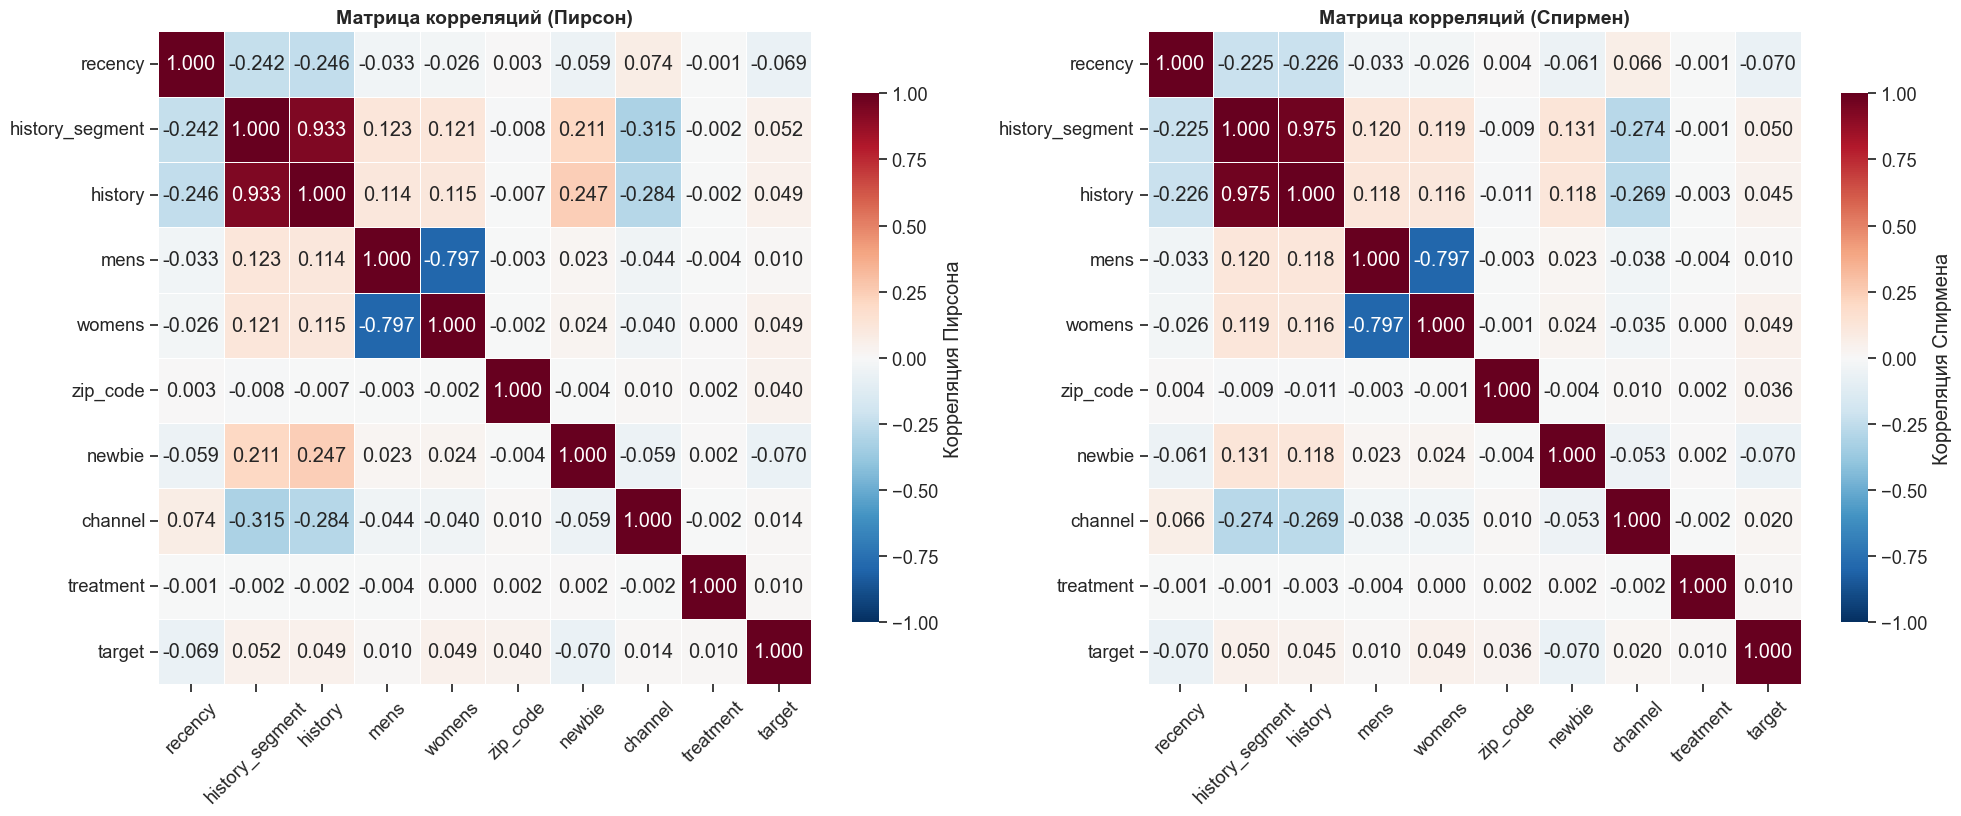

In [50]:
# Визуализация корреляционной матрицы (полная)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Тепловая карта для корреляции Пирсона
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.3f',
            cmap='RdBu_r',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Корреляция Пирсона"},
            ax=axes[0])
axes[0].set_title('Матрица корреляций (Пирсон)', fontweight='bold', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Тепловая карта для корреляции Спирмена
sns.heatmap(corr_matrix_spearman, 
            annot=True, 
            fmt='.3f',
            cmap='RdBu_r',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Корреляция Спирмена"},
            ax=axes[1])
axes[1].set_title('Матрица корреляций (Спирмен)', fontweight='bold', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

In [54]:
# ВЫВОДЫ ПО КОРРЕЛЯЦИОННОМУ АНАЛИЗУ

print("="*70)
print("ВЫВОДЫ ПО РЕЗУЛЬТАТАМ КОРРЕЛЯЦИОННОГО АНАЛИЗА")
print("="*70)

# Анализ корреляций с target
target_corr = corr_matrix['target'].sort_values(ascending=False)
target_corr_spearman = corr_matrix_spearman['target'].sort_values(ascending=False)

print("\nКОРРЕЛЯЦИИ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (TARGET):")
print("-" * 60)
print("\n   Наибольшая положительная корреляция:")
for feat, corr in target_corr.head(3).items():
    if feat != 'target':
        print(f"   • {feat}: {corr:.4f} (Пирсон), {target_corr_spearman[feat]:.4f} (Спирмен)")

print("\n   Наибольшая отрицательная корреляция:")
for feat, corr in target_corr.tail(3).items():
    if feat != 'target':
        print(f"   • {feat}: {corr:.4f} (Пирсон), {target_corr_spearman[feat]:.4f} (Спирмен)")


ВЫВОДЫ ПО РЕЗУЛЬТАТАМ КОРРЕЛЯЦИОННОГО АНАЛИЗА

КОРРЕЛЯЦИИ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (TARGET):
------------------------------------------------------------

   Наибольшая положительная корреляция:
   • history_segment: 0.0517 (Пирсон), 0.0499 (Спирмен)
   • history: 0.0493 (Пирсон), 0.0449 (Спирмен)

   Наибольшая отрицательная корреляция:
   • treatment: 0.0098 (Пирсон), 0.0098 (Спирмен)
   • recency: -0.0692 (Пирсон), -0.0701 (Спирмен)
   • newbie: -0.0701 (Пирсон), -0.0701 (Спирмен)


Сделайте вывод о корреляциях признаков друг с другом и таргетом в этой ячейке.

КОРРЕЛЯЦИИ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ 
Наибольшая положительная корреляция:
   • history_segment: 0.0517 (Пирсон), 0.0499 (Спирмен)
   • history: 0.0493 (Пирсон), 0.0449 (Спирмен)

   Наибольшая отрицательная корреляция:
   • treatment: 0.0098 (Пирсон), 0.0098 (Спирмен)
   • recency: -0.0692 (Пирсон), -0.0701 (Спирмен)
   • newbie: -0.0701 (Пирсон), -0.0701 (Спирмен)


## Выводы по EDA
- Абсолютный lift от промокода: 0.75 п.п.
- Относительный lift: 4.92%
- Соотношение групп: Контрольная 66.4%, Тестовая 33.6%
- Распределение таргета в группах: Контрольная 15.3%, Тестовая 16.0%
- Есть дисбаланс в классах
- Входе стат. теста было определенно, что результат воздействия стат значим
- Есть корреляции между признаками и таргетом, но значения < 0.1 => линейные модели (например лог рег) будет неэффективна

Нжны модели, которые могут находить нелинейные зависимости, например: CatBoost, XGBoost, Случайный лес

Из-за дисбаланса классов лучше выбирать модели, которые учитывают это.



## Этап 3

Обоснуйте выбор конкретной uplift модели в данной ячейке

**T-learner с CatBoost** является оптимальным выбором для baseline-модели, так как:

1. Учитывает разные размеры групп
2. Работает с дисбалансом классов
3. Справится со слабыми корреляциями
4. Прост в реализации и интерпретации
5. Позволит быстро получить работающий прототип

В случае успеха baseline, можно будет перейти к более сложным моделям (например X-learner) для улучшения качества.

### Советы по обучению и инференсу моделей
1. Некоторые uplift модели из библиотеки `causalml` будут требовать категориальные значения воздействия. Для этого используйте маппинг
#### Пример использования маппинга
```python
treatment_mapping = {
    0: 'control',
    1: 'treatment'
}
treatment_train_mapped = treatment_train.map(treatment_mapping)
treatment_test_mapped = treatment_test.map(treatment_mapping)
```

2. При вызове метода `.predict` и получения метрик для тестовой выборки не забывайте применять к прогнозам метод `squeeze()`, чтобы преобразовать многомерный массив в одномерный, что поможет получить адекватные метрики.

3. Для воспроизводимости результатов и объективной оценки не забывайте применять `random_state=42` для моделей, а также при разделении выборки

### Разбиение выборки на тренировочную и тестовую

In [67]:
from sklearn.model_selection import train_test_split

data = df.copy()

# разделим данные на признаки и целевую переменную
X = data.drop(['target'], axis=1)
y = data['target']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                    stratify=data[['target', 'treatment']],
                                    random_state=42)

treatment_mapping = {
    0: 'control',
    1: 'treatment'
}
T_train = X_train['treatment'].map(treatment_mapping)
T_test = X_test['treatment'].map(treatment_mapping)
X_train = X_train.drop(['treatment'], axis=1)
X_test = X_test.drop(['treatment'], axis=1)

### Обучение выбранного бейзлайна

In [68]:
from catboost import CatBoostClassifier
from causalml.inference.meta import BaseTClassifier

base_model_params = {
    "n_estimators": 100,
    "max_depth": 6,
    "random_state": 42
}
# создаём базовые модели для тестовой и контрольной групп 
treatment_model = CatBoostClassifier(
    **base_model_params
)

control_model = CatBoostClassifier(
    **base_model_params
)

# инициализируем T-learner
t_learner = BaseTClassifier(
    treatment_learner=treatment_model,
    control_learner=control_model,
    control_name='control',  # название контрольной группы в столбце treatment
)
# обучаем T-learner
t_learner.fit(
    X=X_train,  
    treatment=T_train,       # Столбец с признаком воздействия
    y=y_train                            # Целевая переменная
)

# получаем предсказания для тестовой выборки
uplift_pred = t_learner.predict(X_test)



Learning rate set to 0.364982
0:	learn: 0.5471687	total: 2ms	remaining: 198ms
1:	learn: 0.4821329	total: 3.07ms	remaining: 151ms
2:	learn: 0.4494698	total: 3.88ms	remaining: 125ms
3:	learn: 0.4302870	total: 5.05ms	remaining: 121ms
4:	learn: 0.4209783	total: 6.13ms	remaining: 116ms
5:	learn: 0.4160845	total: 7.32ms	remaining: 115ms
6:	learn: 0.4128453	total: 8.43ms	remaining: 112ms
7:	learn: 0.4119847	total: 9.04ms	remaining: 104ms
8:	learn: 0.4104660	total: 10.1ms	remaining: 102ms
9:	learn: 0.4093435	total: 11.3ms	remaining: 102ms
10:	learn: 0.4088803	total: 12.1ms	remaining: 98.1ms
11:	learn: 0.4084714	total: 13.2ms	remaining: 97.1ms
12:	learn: 0.4081462	total: 14.3ms	remaining: 96ms
13:	learn: 0.4078698	total: 15.5ms	remaining: 95.2ms
14:	learn: 0.4075692	total: 16.8ms	remaining: 95ms
15:	learn: 0.4074763	total: 17.8ms	remaining: 93.2ms
16:	learn: 0.4072043	total: 18.8ms	remaining: 91.8ms
17:	learn: 0.4070432	total: 19.9ms	remaining: 90.8ms
18:	learn: 0.4067583	total: 21ms	remaining:

### Расчет метрик для выбранного бейзлайна на тестовой выборке

In [48]:
def uplift_k_score(top_percent: int, uplift: np.ndarray):
    return pd.Series(uplift_pred.squeeze(), name='uplift').sort_values(ascending=False).head(int(len(uplift) * top_percent)).mean()

In [104]:
from sklift.metrics import uplift_auc_score, qini_auc_score

uplift_score = uplift_auc_score(
    y_test.values, 
    uplift_pred.squeeze(), 
    T_test.map({'control': 0, 'treatment': 1}).values
)
qini_score = qini_auc_score(
    y_test.values, 
    uplift_pred.squeeze(), 
    T_test.map({'control': 0, 'treatment': 1}).values
)
uplift_30_score = uplift_k_score(0.3, uplift_pred)

print(f"Uplift AUC: {uplift_score:.4f}")
print(f"Qini AUC: {qini_score:.4f}")
print(f"Uplift@30%: {uplift_30_score:.4f}")

Uplift AUC: 0.0055
Qini AUC: 0.0119
Uplift@30%: 0.0754


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split

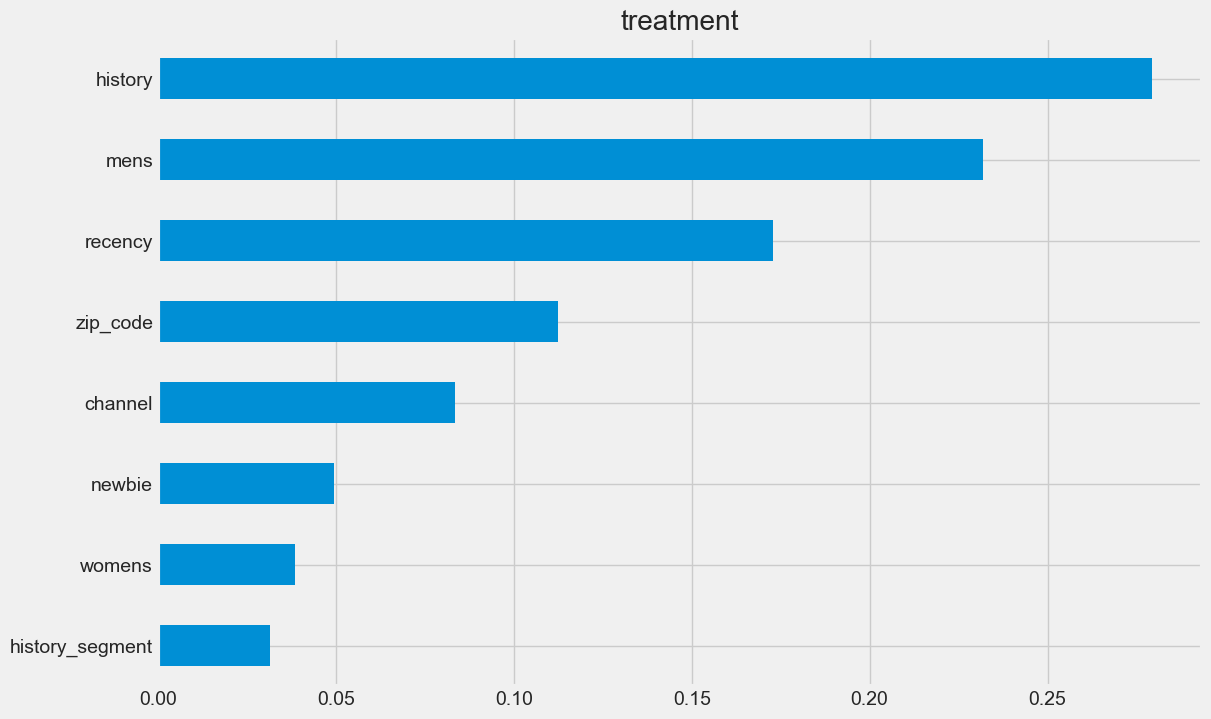

In [ ]:
# График важности признаков
t_learner.plot_importance(X=X_test, tau=uplift_pred.squeeze(), features=X_test.columns.tolist())


# Обучение 2 моделей 

### Обучение модели 1

In [ ]:
from causalml.inference.meta import BaseSLearner


learner = CatBoostClassifier(**base_model_params)

s_learner = BaseSLearner(learner=learner, control_name='control')
s_learner.fit(X=X_train, treatment=T_train, y=y_train)

uplift_vals_2 = s_learner.predict(X_test.values.copy())


### Получение метрик по модели 1

Uplift AUC: -0.0020
Qini AUC: -0.0045
Uplift@30%: 0.0754
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped trai

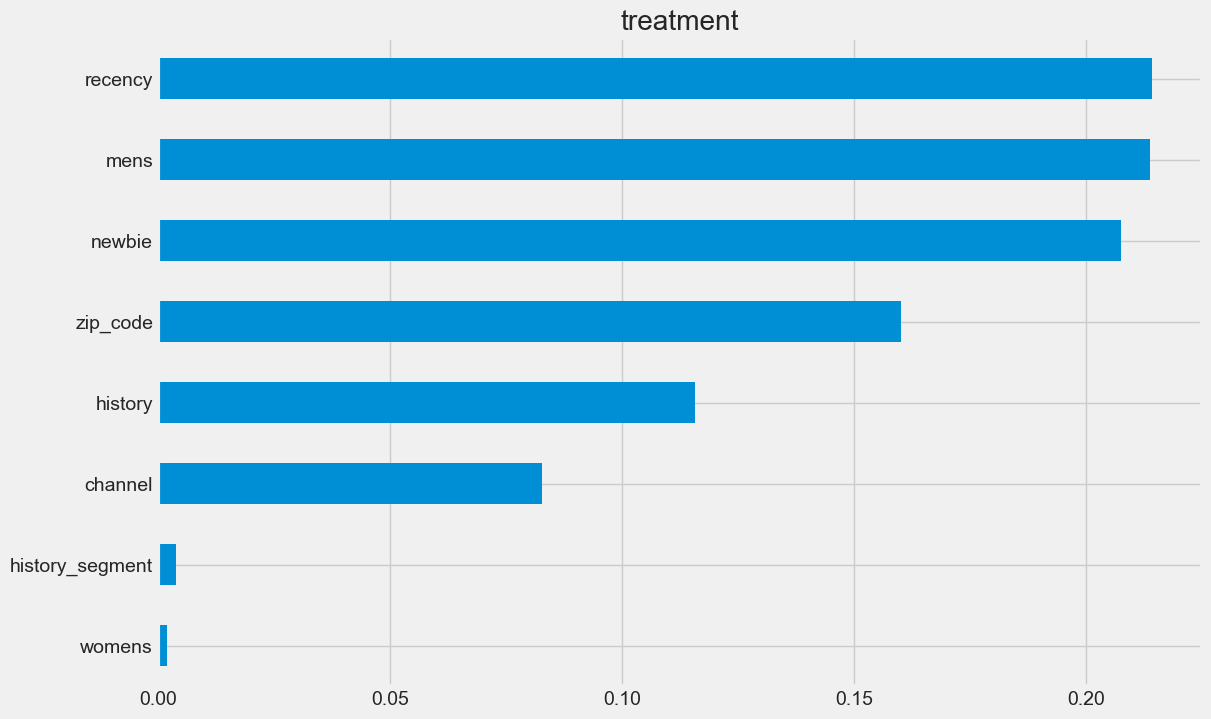

In [103]:
uplift_score = uplift_auc_score(
    y_test.values, 
    uplift_vals_2.squeeze(), 
    T_test.map({'control': 0, 'treatment': 1}).values
)
qini_score = qini_auc_score(
    y_test.values, 
    uplift_vals_2.squeeze(), 
    T_test.map({'control': 0, 'treatment': 1}).values
)
uplift_30_score = uplift_k_score(0.3, uplift_vals_2)

print(f"Uplift AUC: {uplift_score:.4f}")
print(f"Qini AUC: {qini_score:.4f}")
print(f"Uplift@30%: {uplift_30_score:.4f}")

s_learner.plot_importance(X=X_test, tau=uplift_vals_2.squeeze(), features=X_test.columns.tolist())

### Обучение модели 2

In [ ]:
from causalml.inference.meta import BaseXClassifier
from catboost import CatBoostRegressor

outcome_learner = CatBoostClassifier(**base_model_params)
effect_learner = CatBoostRegressor(**base_model_params)

x_learner = BaseXClassifier(outcome_learner=outcome_learner, effect_learner=effect_learner, control_name='control')
x_learner.fit(X=X_train, treatment=T_train, y=y_train)

uplift_vals_3 = x_learner.predict(X_test.values.copy())

### Получение метрик по модели 2

Uplift AUC: 0.0065
Qini AUC: 0.0138
Uplift@30%: 0.0754
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped traini

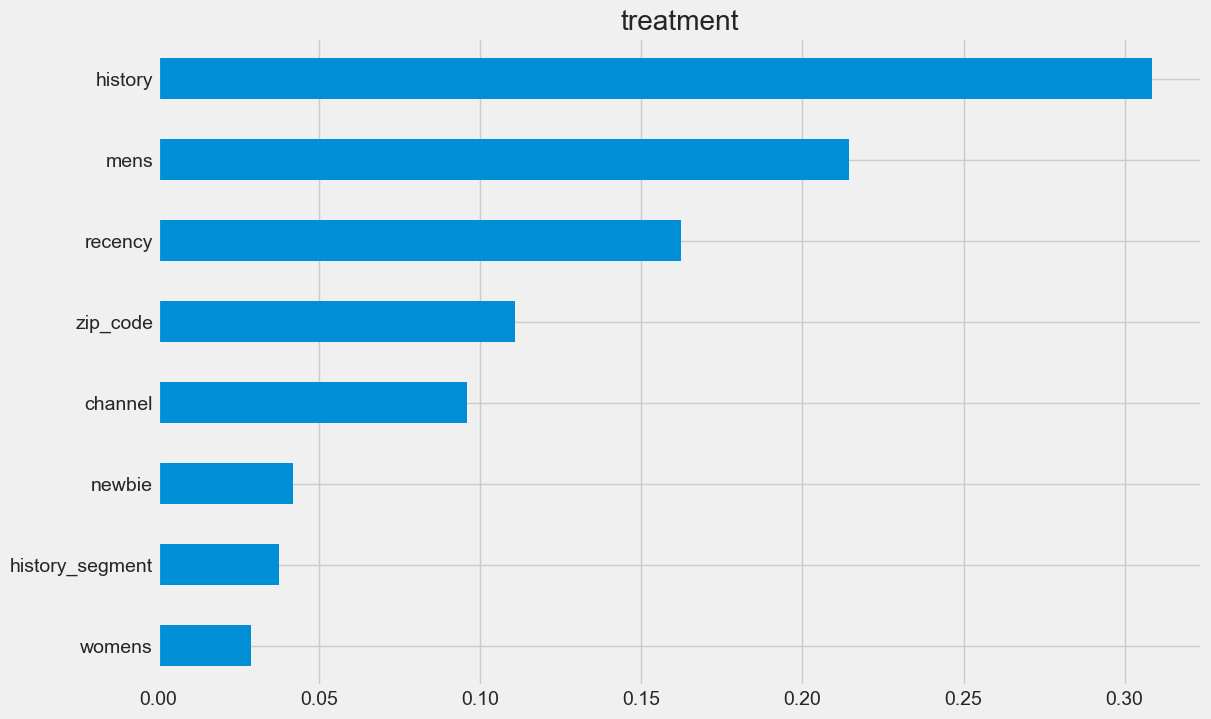

In [102]:
uplift_score = uplift_auc_score(
    y_test.values, 
    uplift_vals_3.squeeze(), 
    T_test.map({'control': 0, 'treatment': 1}).values
)
qini_score = qini_auc_score(
    y_test.values, 
    uplift_vals_3.squeeze(), 
    T_test.map({'control': 0, 'treatment': 1}).values
)
uplift_30_score = uplift_k_score(0.3, uplift_vals_3)

print(f"Uplift AUC: {uplift_score:.4f}")
print(f"Qini AUC: {qini_score:.4f}")
print(f"Uplift@30%: {uplift_30_score:.4f}")

x_learner.plot_importance(X=X_test, tau=uplift_vals_3.squeeze(), features=X_test.columns.tolist())

Проинтерпретируйте полученные результаты и обоснуйте выбор 1 модели в этой ячейке


## 1. Сводная таблица метрик

| Модель | Uplift AUC | Qini AUC | Uplift@30% |
|--------|------------|----------|------------|
| **T-Learner (baseline)** | 0.0055 | 0.0119 | 0.0754 |
| **S-Learner** | -0.0020 | -0.0045 | 0.0754 |
| **X-Learner** | **0.0065** | **0.0138** | **0.0754** |

### T-Learner (baseline)
- **Uplift AUC: 0.0055** - небольшое положительное значение, модель лучше случайной
- **Qini AUC: 0.0119** - умеренное качество ранжирования
- **Uplift@30%: 0.0754** - хороший результат в топ-сегменте

**Сильные стороны:**
- Положительные метрики по всем показателям
- Стабильная работа
- Хорошо справляется с разными размерами групп

### S-Learner
- **Uplift AUC: -0.0020** - хуже случайной модели
- **Qini AUC: -0.0045** - отрицательное качество ранжирования
- **Uplift@30%: 0.0754** - тот же результат в топ-сегменте

**Проблемы:**
- Отрицательные AUC говорят о том, что модель работает хуже случайного выбора
- Treatment-эффект "задавлен" другими признаками
- Одна модель не может уловить различия в поведении групп

### X-Learner
- **Uplift AUC: 0.0065** - лучший результат среди всех моделей
- **Qini AUC: 0.0138** - также лучший показатель
- **Uplift@30%: 0.0754** - идентичный результат в топ-сегменте

**Сильные стороны:**
- Наилучшие метрики качества
- Лучше всех ранжирует пользователей по uplift'у
- Учитывает гетерогенность эффектов


### По значением метрик для этих данных x-learner показал лучшие результаты + работает лучше на несбалансированных данных чем S,T - learner


# Часть 2

## Этап 1
Улучшите бейзлайн выбранной модели

#### Генерация признаков (опционально)

### Подбор гиперпараметров

In [ ]:
from optuna import create_study
from sklift.metrics import uplift_at_k

def objective(trial):
    # Дополните код для подбора гиперпараметров

    uplift_at_30 = uplift_at_k(y_test, uplift_pred, treatment_test, k=0.3, strategy='overall')
    return uplift_at_30

# Создаем и запускаем исследование
study = create_study(direction='maximize')
study.optimize(objective, n_trials=100)

# Выводим лучшие гиперпараметры
print("Best hyperparameters: ", study.best_params)
print("Best score: ", study.best_value)


## Этап 2

### Визуализация результатов

In [ ]:
from utils import custom_uplift_by_percentile

В данной ячейке сделайте вывод о качестве работы модели и проинтерпретируйте график `uplift by percentile` 

# Этап 3

In [138]:
# Класс для инференса модели
class UpliftModelInference:
    """
    Класс для инференса uplift модели.
    """
    
    def __init__(self, model, feature_names, logger=None):
        """
        Инициализация класса.
        
        Аргументы:
            model: Обученная модель uplift
            feature_names: Список признаков для предсказания 
            logger: Объект для логирования (по умолчанию None)
        """
        self.model = model
        self.feature_names = ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']
        self.logger = logger
        
        if self.logger:
            self.logger.info("Модель UpliftModel инициализирована с признаками: %s", feature_names)

    def _transform_data(self, X):
        """
        Преобразование данных для модели.
        
        Аргументы:
            X: pandas.DataFrame с признаками
        """
        if self.logger:
            self.logger.debug("Преобразование входных данных размерности %s", X.shape)

        # реализуйте преобразование данных для модели,
        # если в финальной модели используются новые признаки
       

        return X
    
    def predict(self, X):
        """
        Получение предсказаний uplift.
        
        Аргументы:
            X: pandas.DataFrame с признаками
            
        Возвращает:
            numpy.array с предсказанными значениями uplift
        """
        # Проверяем, что датафрейм не пустой
        if X.empty:
            if self.logger:
                self.logger.error("Предоставлен пустой датафрейм")
            return None
            
        # Проверяем наличие пропущенных значений
        if X.isnull().any().any():
            if self.logger:
                self.logger.error("Входные данные содержат пропущенные значения")
            return [None]*len(X)
        
        if self.logger:
            self.logger.info("Выполняем предсказания для данных размерности %s", X.shape)

        # Проверяем наличие всех необходимых признаков
        missing_features = set(self.feature_names) - set(X.columns)
        if missing_features:
            error_msg = f"Отсутствуют признаки: {missing_features}"
            if self.logger:
                self.logger.error(error_msg)

            return [None]*len(X)
        
        # Преобразуем данные для модели
        if self.logger:
            self.logger.debug("Начинаем преобразование данных")
        X = self._transform_data(X)
        
        # Вычисляем uplift
        if self.logger:
            self.logger.debug("Выполняем предсказания модели")
        

        # Дополните код для получения предсказаний аплифта

        
        if self.logger:
            self.logger.info("Предсказания успешно завершены")
            
        return uplift


In [126]:
model = UpliftModelInference(model= # ваш код,
                             feature_names= # ваш код)

In [ ]:
test_data = pd.DataFrame({
            'recency': [1, 2, 3],
            'history_segment': [1, 2, 3], 
            'history': [100, 200, 300],
            'mens': [1, 0, 1],
            'womens': [0, 1, 0],
            'zip_code': [1, 0, 1],
            'newbie': [0, 1, 0],
            'channel': [1, 2, 0]
        })

In [ ]:
# проверка работы класса
model.predict(test_data)